In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv
/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_binary_health_indicators_BRFSS2015.csv
/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_012_health_indicators_BRFSS2015.csv


# Loading DataSet
Loading the diabetes file in the csv format so that kaggle could work with data easily.

In [2]:
df = pd.read_csv('/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_binary_health_indicators_BRFSS2015.csv')

df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


**Check DataSet Shape**

In [3]:
df.shape

(253680, 22)

**Data Information**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

# Statistical Analysis 

**Describing Dataset**

In [5]:
df.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


**Checking Missing Values**

In [6]:
df.isnull().sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

**Checking Target Distribution**

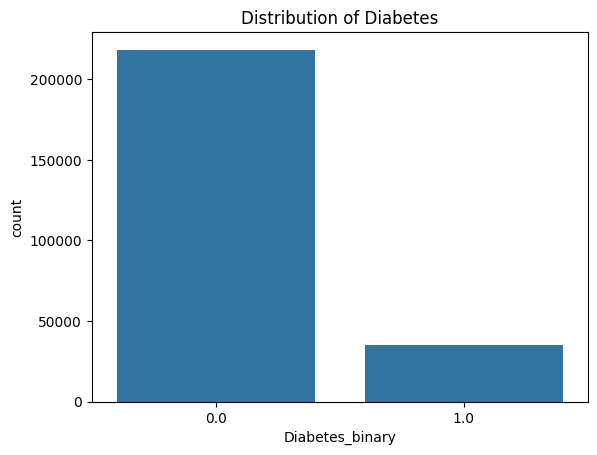

In [7]:
sns.countplot(x = 'Diabetes_binary', data=df)
plt.title("Distribution of Diabetes")
plt.show()

# Visual analysis 
**Distribution of BMI**

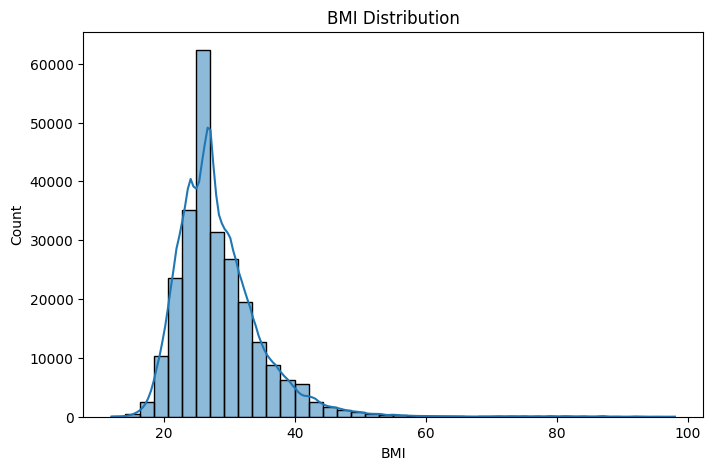

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['BMI'], bins = 40, kde = True)
plt.title("BMI Distribution")
plt.show()

**Age Distribution**

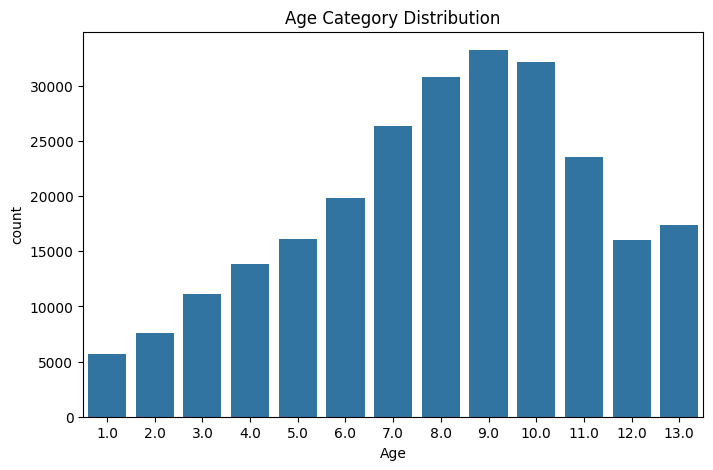

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x='Age', data=df)
plt.title("Age Category Distribution")
plt.show()

**BMI vs Diabetes**

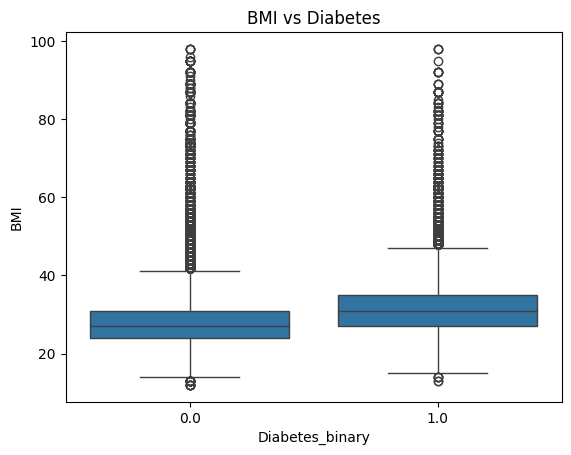

In [10]:
sns.boxplot(x='Diabetes_binary', y='BMI', data=df)
plt.title("BMI vs Diabetes")
plt.show()

**High Blood Pressure vs Diabetes**

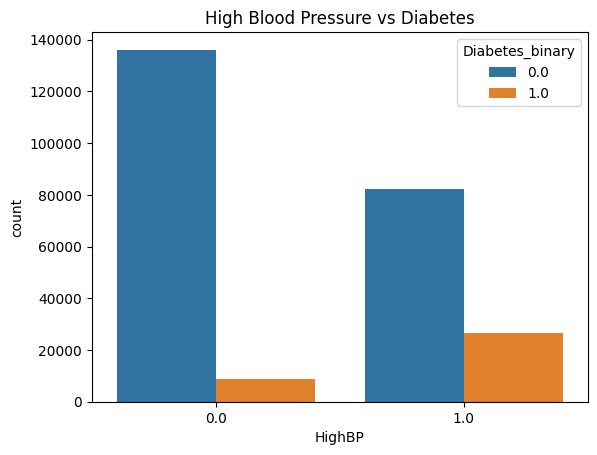

In [11]:
sns.countplot(x='HighBP', hue='Diabetes_binary', data=df)
plt.title("High Blood Pressure vs Diabetes")
plt.show()

**Histograms for all other features**

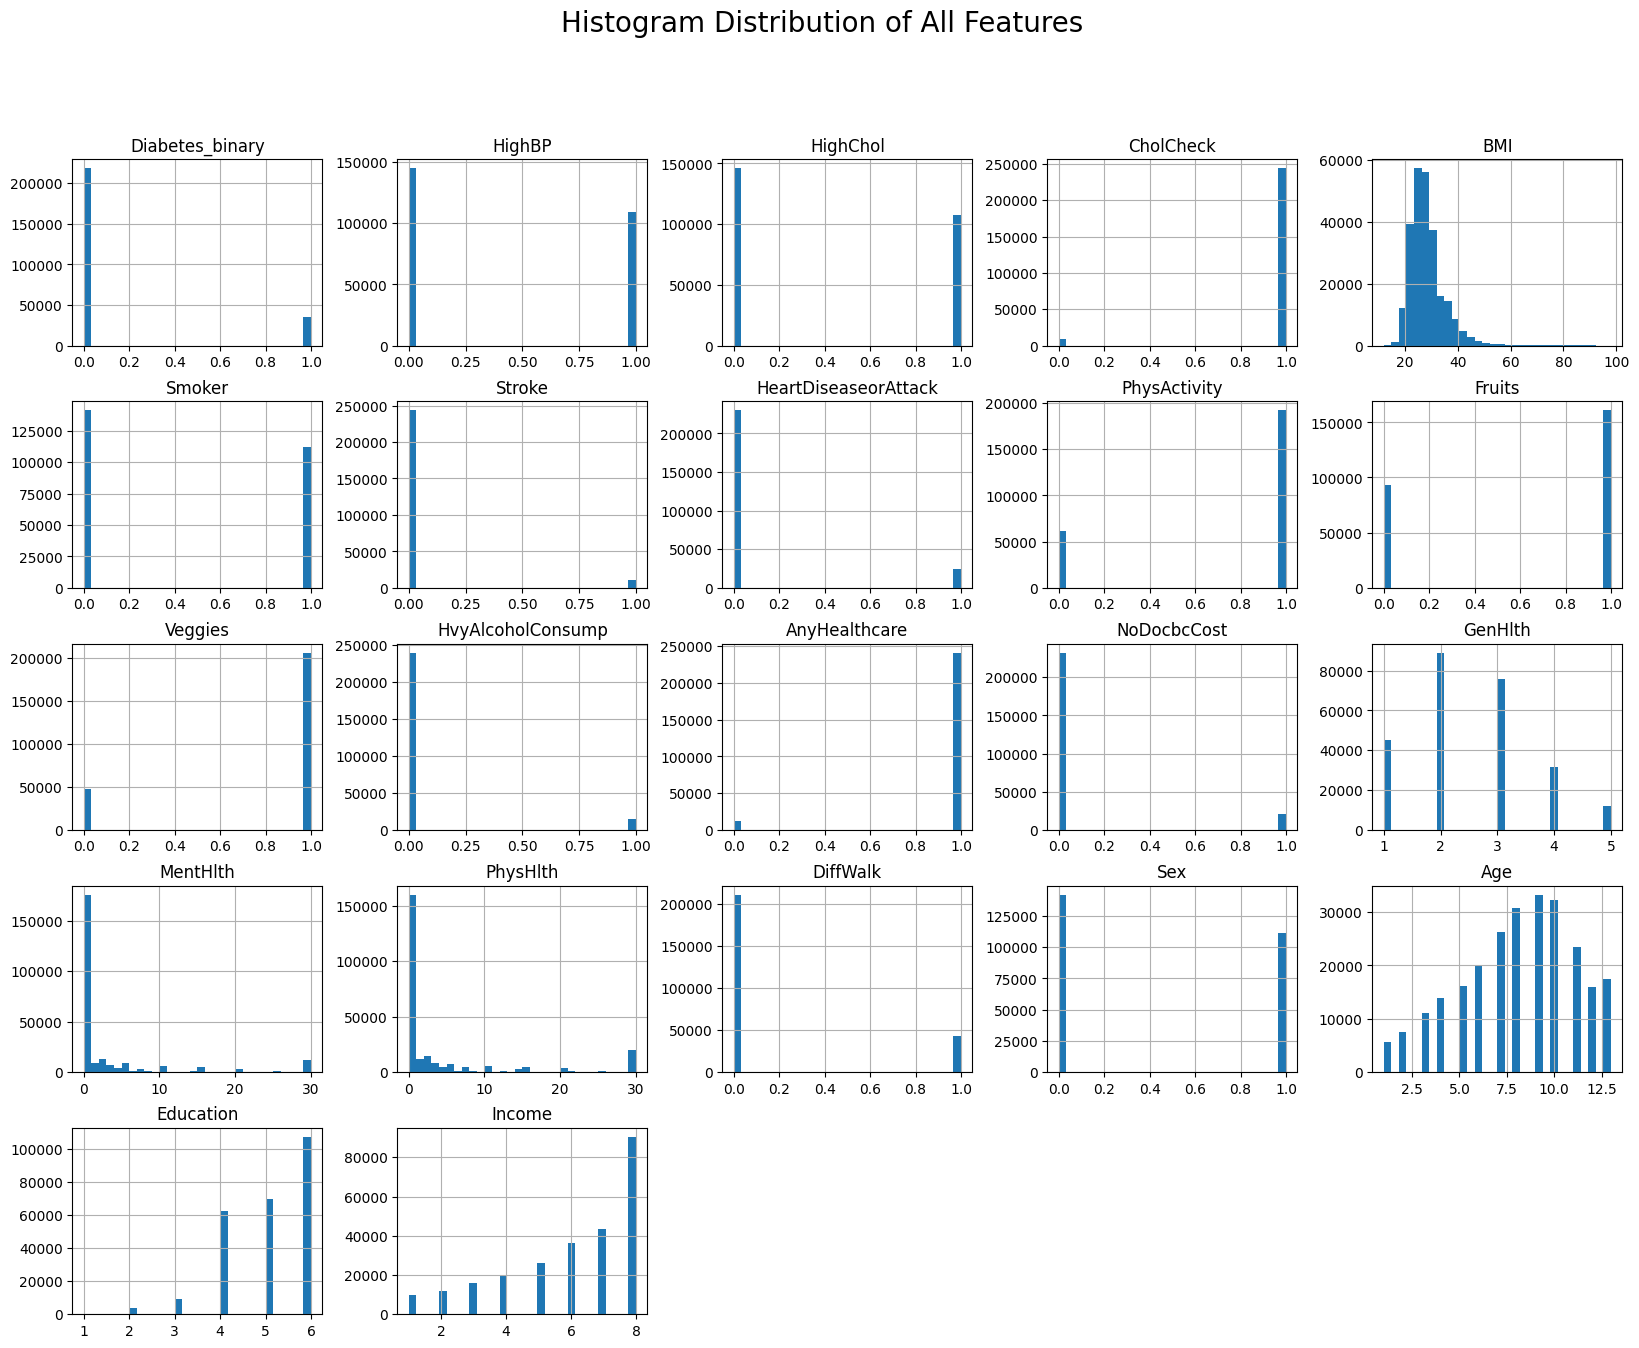

In [12]:
df.hist(figsize=(20,15), bins=30)
plt.suptitle("Histogram Distribution of All Features", fontsize=20)
plt.show()

**Boxplot of all other features with respect to Diabetes**

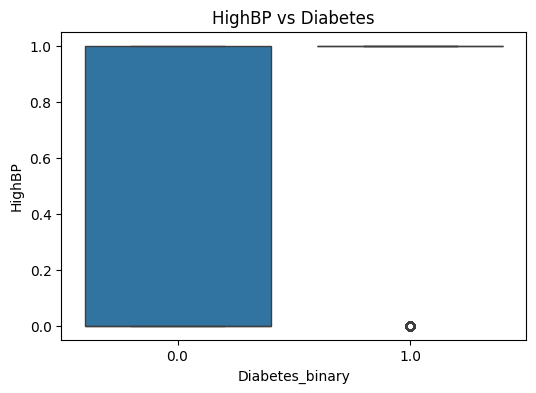

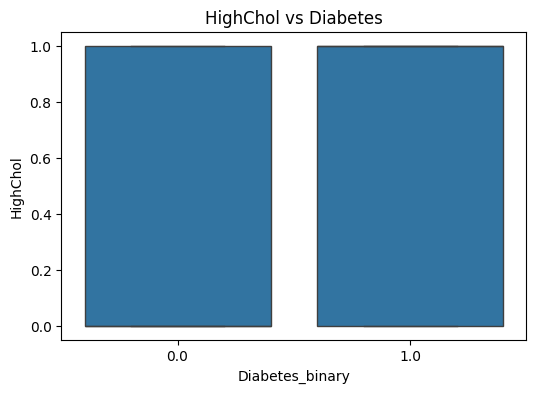

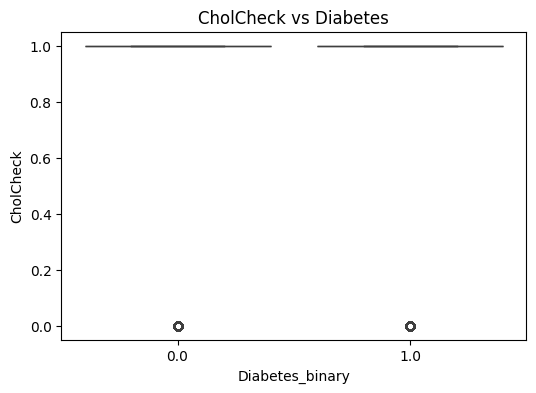

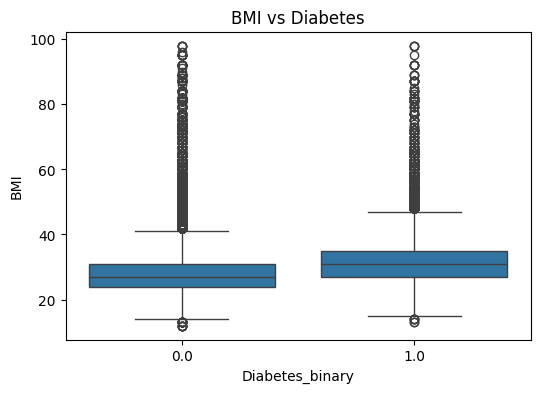

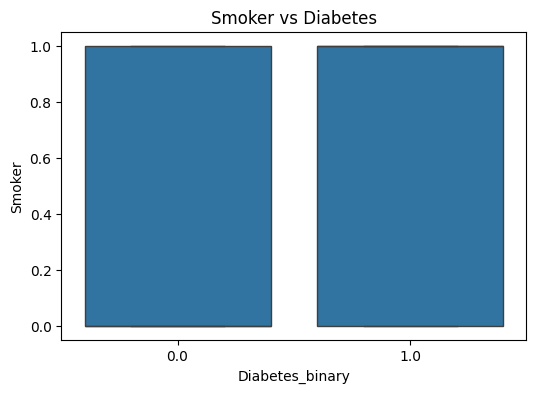

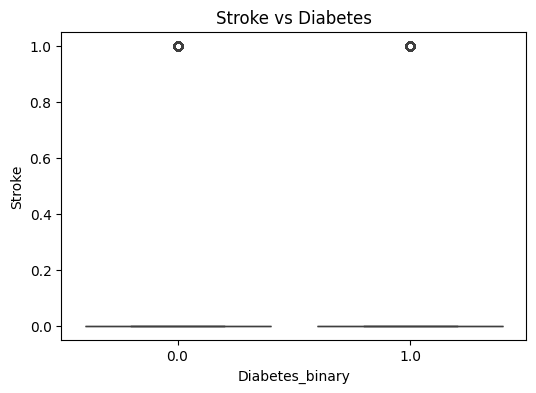

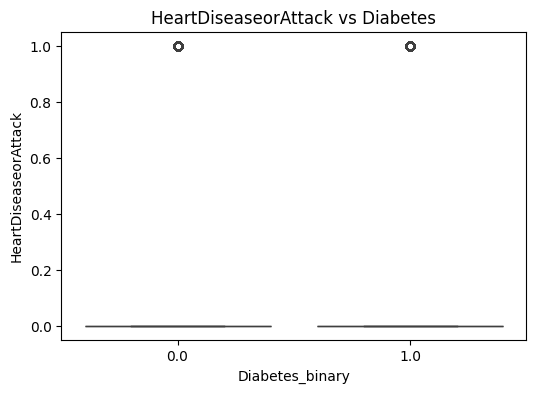

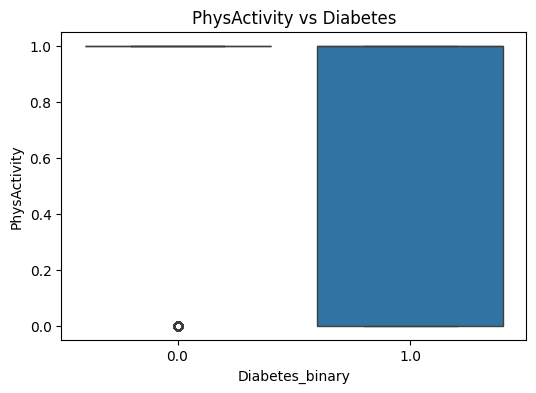

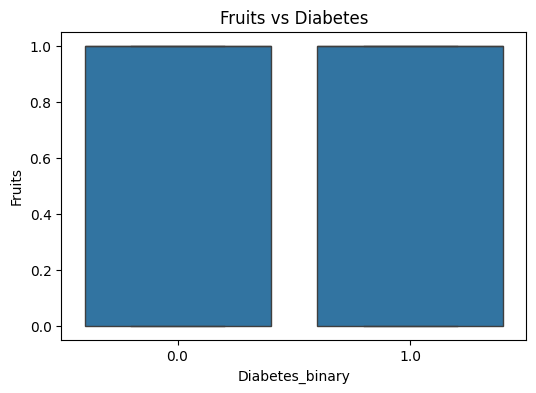

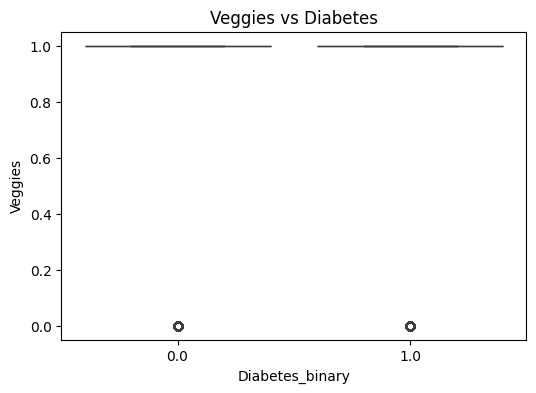

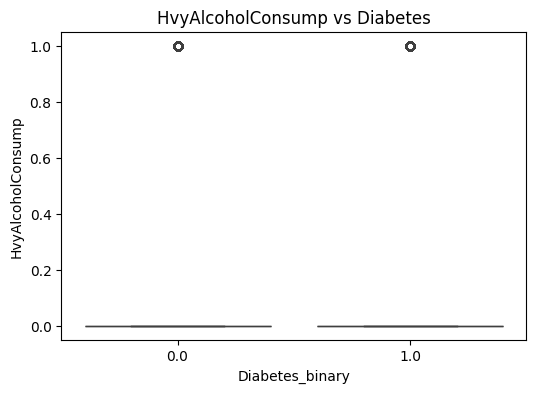

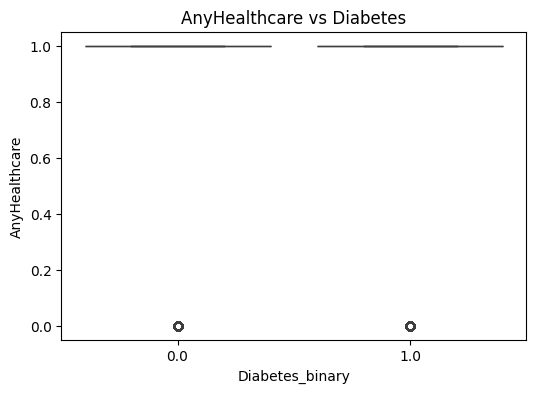

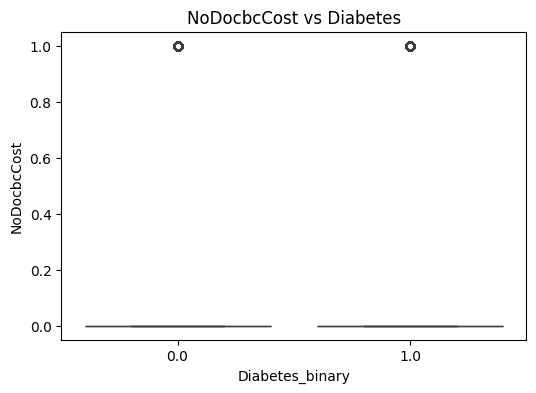

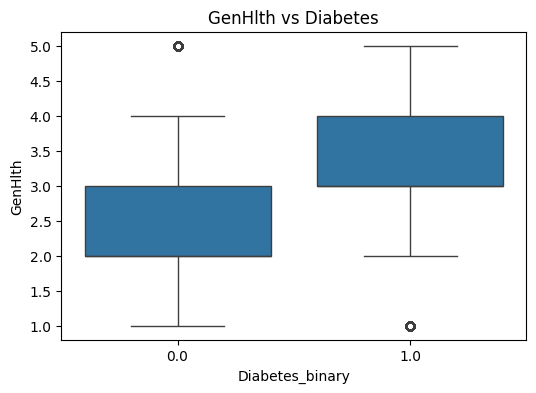

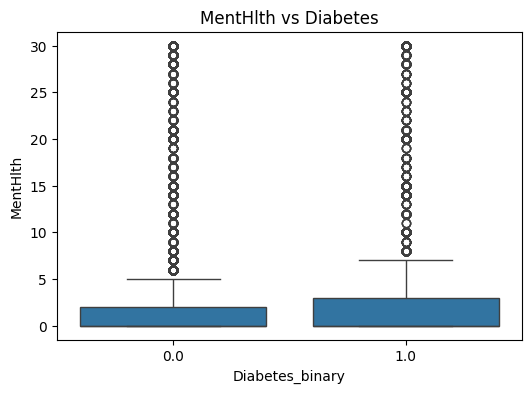

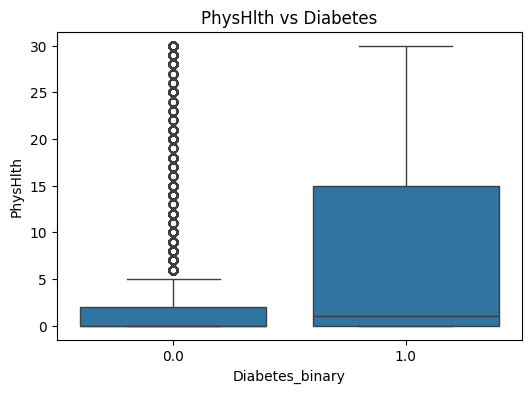

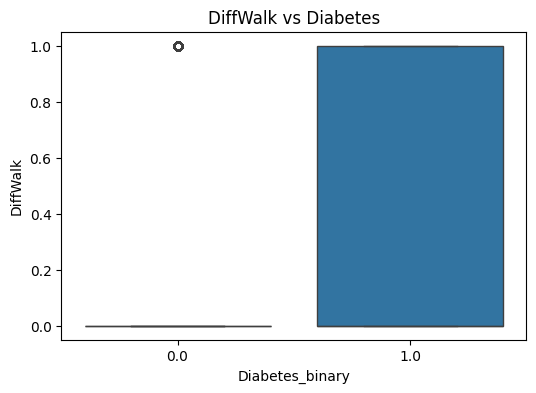

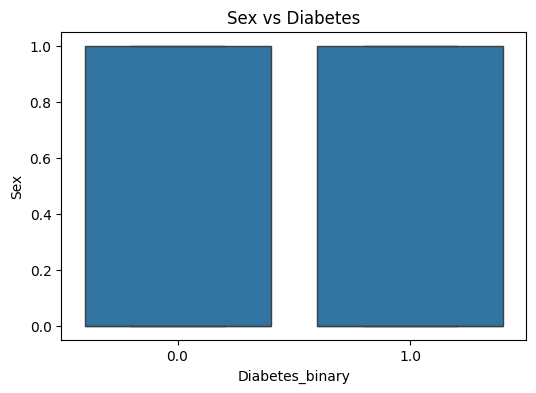

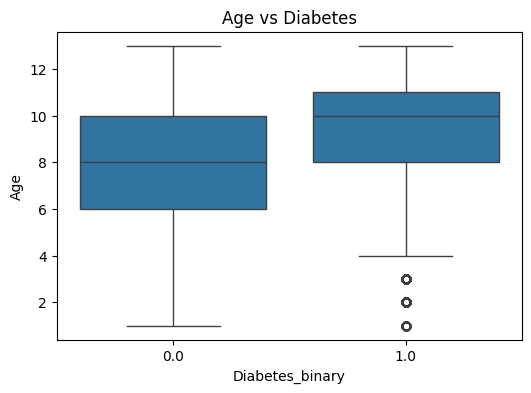

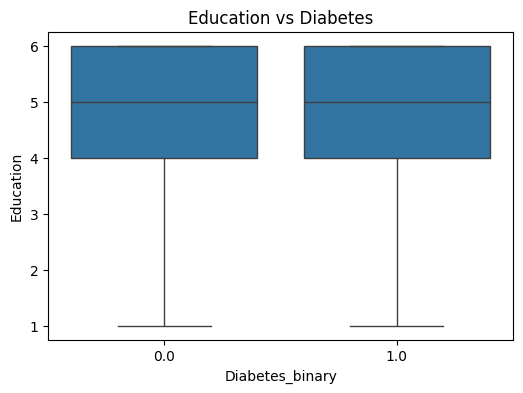

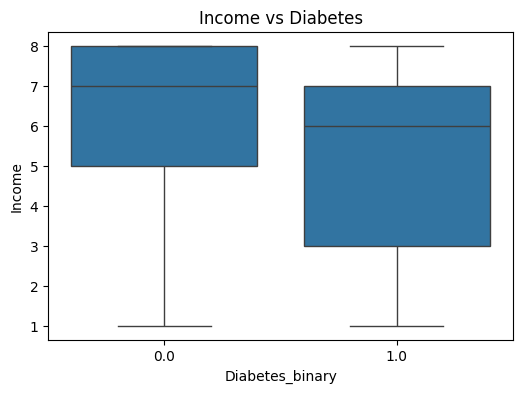

In [13]:
target = 'Diabetes_binary'

for col in df.columns:
    if col != target:
        plt.figure(figsize=(6,4))
        sns.boxplot(x=df[target], y=df[col])
        plt.title(f"{col} vs Diabetes")
        plt.show()

**Heat Map of the Features**

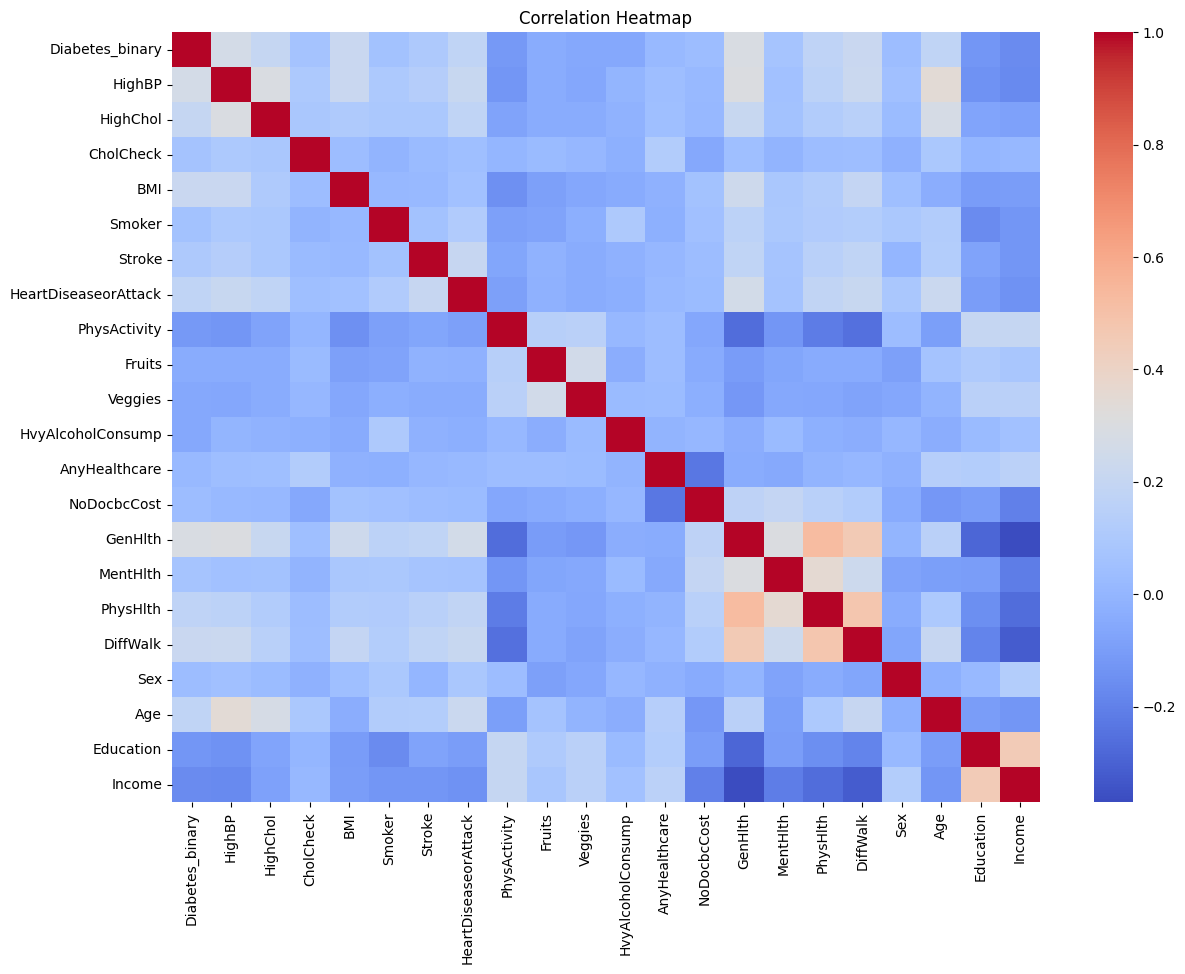

In [14]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Observation
Key correlations appear between:


*BMI
HighBP
HighChol
Age*


These features strongly relate to diabetes risk.

# Preprocessing 


**Remove Duplicate Rows**

In [15]:
df = df.drop_duplicates()

In [16]:
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [17]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


**Feature scaling**

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['BMI'] = scaler.fit_transform(df[['BMI']])

# Save Preprocessed Dataset

In [19]:
df.to_csv("diabetes_preprocessed.csv", index=False)

# Feature Engineering

In [20]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,1.666251,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,-0.543144,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,-0.101265,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,-0.248558,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,-0.690437,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


# 5 methods for Finding important Features

**Method 1 : Correlation**

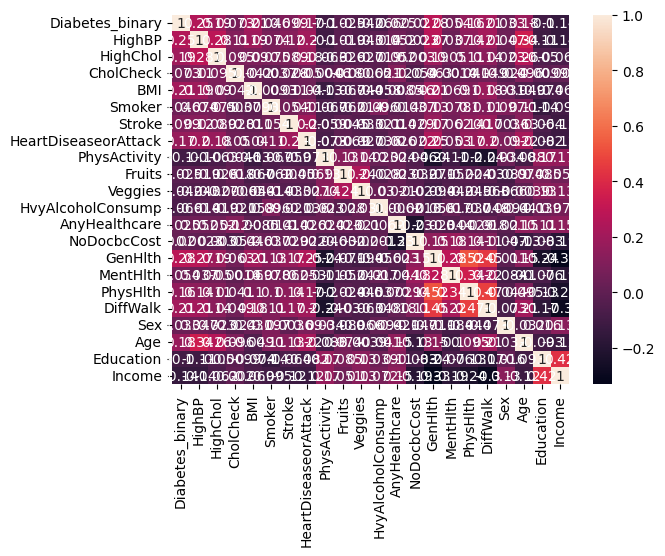

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()
sns.heatmap(corr, annot=True)
plt.show()

Which features are strongly related to outcome (Diabetes)

**Method 2: Random Forest Feature Importance**

<Axes: >

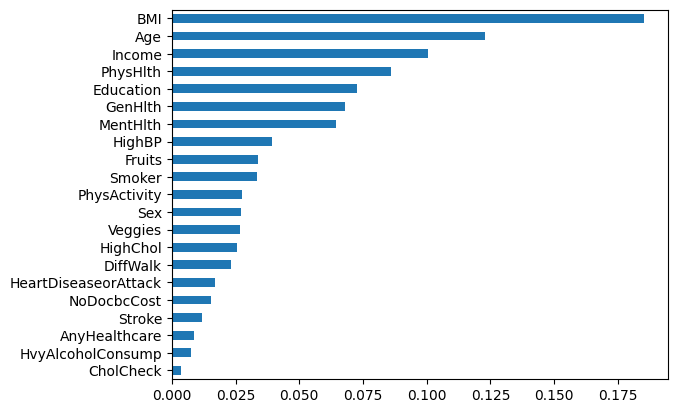

In [22]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

model = RandomForestClassifier()
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

**Method 3: Logistic Regression (coefficients)**

<Axes: >

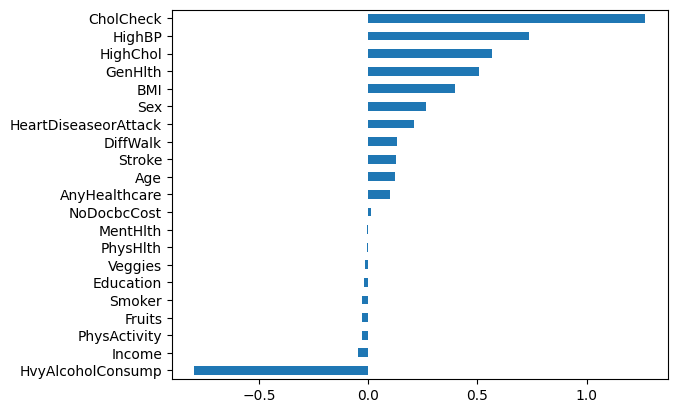

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

pd.Series(model.coef_[0], index=X.columns).sort_values().plot(kind='barh')

**Method 4: SHAP**

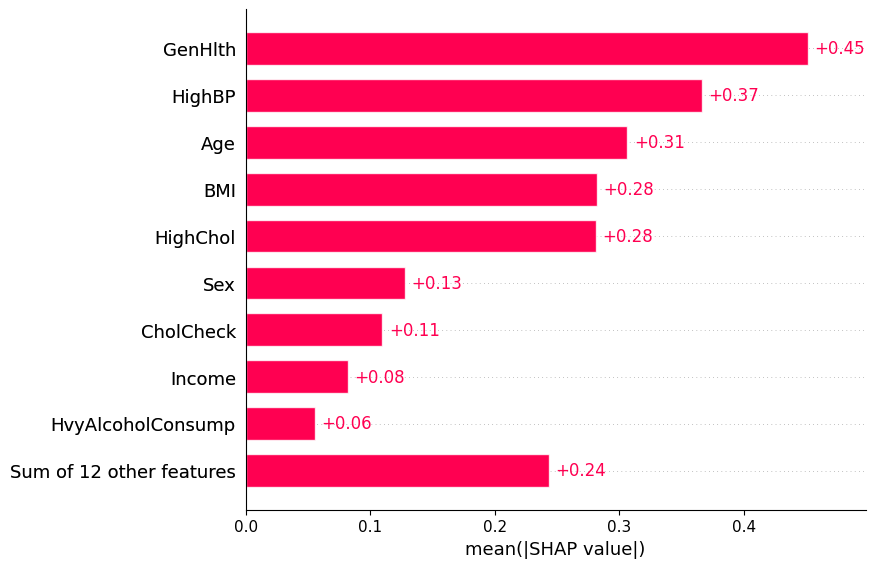

In [24]:
import shap

explainer = shap.Explainer(model, X)
shap_values = explainer(X)

shap.plots.bar(shap_values)

**Method 5: LIME**

In [25]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(X.values, feature_names=X.columns, class_names=['No','Yes'])

exp = explainer.explain_instance(X.values[0], model.predict_proba)
exp.show_in_notebook()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


# STEP 3: Create New Features

In [26]:
# Age group
df["Age_Group"] = pd.cut(df["Age"], bins=[0,30,50,100], labels=[0,1,2])

# Combined health risk
df["Health_Risk"] = df["HighBP"] + df["HighChol"] + df["Stroke"] + df["HeartDiseaseorAttack"]

# Lifestyle score (healthy habits)
df["Lifestyle_Score"] = df["PhysActivity"] + df["Fruits"] + df["Veggies"]

# BMI with age interaction
df["BMI_Age"] = df["BMI"] * df["Age"]

# Healthcare access issue
df["Healthcare_Issue"] = df["NoDocbcCost"] + (1 - df["AnyHealthcare"])

# Overall poor health
df["Poor_Health"] = df["GenHlth"] + df["MentHlth"] + df["PhysHlth"]

**Health_Risk**

This feature combines multiple health conditions such as high blood pressure and cholesterol to better represent overall risk.

**Lifestyle_Score**

This captures healthy habits like physical activity and diet, which influence diabetes risk.

**BMI_Age**

This interaction feature captures the combined effect of age and obesity.

# STEP 4: Check Performance of New Features 

This here is done by using the LGBM

In [27]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

[LightGBM] [Info] Number of positive: 28015, number of negative: 155564
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029861 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 535
[LightGBM] [Info] Number of data points in the train set: 183579, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.152605 -> initscore=-1.714317
[LightGBM] [Info] Start training from score -1.714317
Accuracy: 0.8517485564876348


LightGBM was used to evaluate the performance of newly engineered features. It is efficient and suitable for quick experimentation. The accuracy here is about **85.1748%**

# STEP 5: Drop Less Important Features

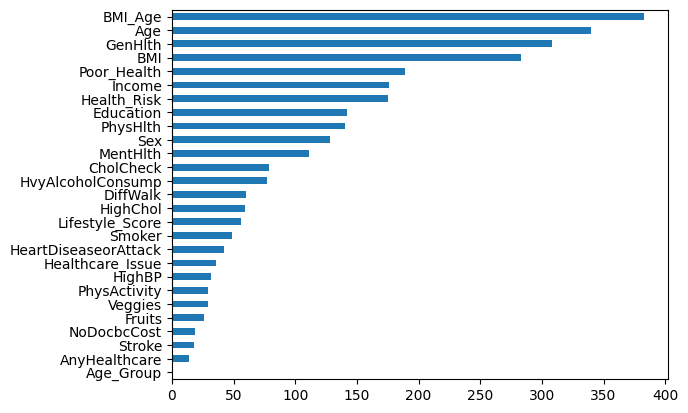

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.show()

In [29]:
cols_to_drop = [
    "BMI_Category",
    "Age_Group",
    "AnyHealthcare",
    "Stroke",
    "NoDocbcCost"
]

existing_cols = [col for col in cols_to_drop if col in df.columns]

df = df.drop(existing_cols, axis=1)

In [30]:
df = df.drop([
    "Fruits",
    "Veggies",
    "PhysActivity"
], axis=1, errors='ignore')

In [31]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,HvyAlcoholConsump,GenHlth,MentHlth,...,DiffWalk,Sex,Age,Education,Income,Health_Risk,Lifestyle_Score,BMI_Age,Healthcare_Issue,Poor_Health
0,0.0,1.0,1.0,1.0,1.666251,1.0,0.0,0.0,5.0,18.0,...,1.0,0.0,9.0,4.0,3.0,2.0,1.0,14.996258,0.0,38.0
1,0.0,0.0,0.0,0.0,-0.543144,1.0,0.0,0.0,3.0,0.0,...,0.0,0.0,7.0,6.0,1.0,0.0,1.0,-3.802008,2.0,3.0
2,0.0,1.0,1.0,1.0,-0.101265,0.0,0.0,0.0,5.0,30.0,...,1.0,0.0,9.0,4.0,8.0,2.0,1.0,-0.911385,1.0,65.0
3,0.0,1.0,0.0,1.0,-0.248558,0.0,0.0,0.0,2.0,0.0,...,0.0,0.0,11.0,3.0,6.0,1.0,3.0,-2.734138,0.0,2.0
4,0.0,1.0,1.0,1.0,-0.690437,0.0,0.0,0.0,2.0,3.0,...,0.0,0.0,11.0,5.0,4.0,2.0,3.0,-7.594806,0.0,5.0


In [32]:
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'HeartDiseaseorAttack', 'HvyAlcoholConsump', 'GenHlth', 'MentHlth',
       'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income',
       'Health_Risk', 'Lifestyle_Score', 'BMI_Age', 'Healthcare_Issue',
       'Poor_Health'],
      dtype='object')

# STEP 6: Re-run Model After Dropping

In [33]:
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("New Accuracy:", accuracy_score(y_test, y_pred))

[LightGBM] [Info] Number of positive: 28015, number of negative: 155564
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016298 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 523
[LightGBM] [Info] Number of data points in the train set: 183579, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.152605 -> initscore=-1.714317
[LightGBM] [Info] Start training from score -1.714317
New Accuracy: 0.8518575008170824


Now the accuracy has been increased a bit i.e **85.1857%**

# STEP 7: Standardization / Normalization

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# STEP 8: Use K-Means to Create New Feature

In [35]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
df["Cluster"] = kmeans.fit_predict(X)

# Step 9: Save Final Dataset

In [36]:
df.to_csv("final_diabetes_dataset.csv", index=False)